In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score

# ========================
# Section 1: Data Preparation
# ========================
print("Loading and preprocessing data...")
# Load the dataset
data = pd.read_csv('as1-bank.csv')

# Separate features and target
X = data.drop('y', axis=1)
y = data['y'].map({'no': 0, 'yes': 1})  # Convert target to binary

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numerical and categorical columns
numerical_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
categorical_cols = ['marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']

# Define preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Create full pipeline that includes preprocessing
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Preprocess data
X_train_preprocessed = full_pipeline.fit_transform(X_train)
X_test_preprocessed = full_pipeline.transform(X_test)

# Convert to dense arrays for TensorFlow
X_train_preprocessed = X_train_preprocessed.toarray() if hasattr(X_train_preprocessed, 'toarray') else X_train_preprocessed
X_test_preprocessed = X_test_preprocessed.toarray() if hasattr(X_test_preprocessed, 'toarray') else X_test_preprocessed

print(f"Preprocessed training shape: {X_train_preprocessed.shape}")
print(f"Preprocessed testing shape: {X_test_preprocessed.shape}")

Loading and preprocessing data...
Preprocessed training shape: (6273, 23)
Preprocessed testing shape: (1569, 23)


In [2]:
# ========================
# Section 2: Architecture Definitions
# ========================
architectures = [
    (10,),         # 1 layer, 10 neurons
    (50,),         # 1 layer, 50 neurons
    (100,),        # 1 layer, 100 neurons
    (30, 20),      # 2 layers: 30 → 20
    (50, 30),      # 2 layers: 50 → 30
    (100, 50),     # 2 layers: 100 → 50
    (100, 80, 50), # 3 layers: 100 → 80 → 50
    (150, 100, 50) # 3 layers: 150 → 100 → 50
]

In [3]:
# ========================
# Section 3: Architecture Comparison with TensorFlow
# ========================
print("\nEvaluating different architectures with TensorFlow...")
best_score = -1
best_arch = None
history_dict = {}

# Define early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Create TensorBoard callback (optional)
# tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="./logs")

for i, arch in enumerate(architectures):
    print(f"\nEvaluating architecture {i+1}/{len(architectures)}: {arch}")
    
    # Build model
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(X_train_preprocessed.shape[1],)))
    
    # Add hidden layers
    for units in arch:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Dropout(0.3))
    
    # Add output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    
    # Train model
    history = model.fit(
        X_train_preprocessed,
        y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Store history for later visualization
    history_dict[arch] = history
    
    # Evaluate on validation set
    val_loss, val_acc, val_precision, val_recall = model.evaluate(
        X_test_preprocessed, y_test, verbose=0
    )
    
    # Calculate F1 score
    val_f1 = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-7)
    
    print(f"Architecture {arch}:")
    print(f"  Validation Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}")
    
    if val_f1 > best_score:
        best_score = val_f1
        best_arch = arch
        best_model = model

print(f"\nBest Architecture: {best_arch} with F1: {best_score:.4f}")


Evaluating different architectures with TensorFlow...

Evaluating architecture 1/8: (10,)
Architecture (10,):
  Validation Accuracy: 0.8337, F1: 0.5877

Evaluating architecture 2/8: (50,)
Architecture (50,):
  Validation Accuracy: 0.8292, F1: 0.5864

Evaluating architecture 3/8: (100,)
Architecture (100,):
  Validation Accuracy: 0.8356, F1: 0.6031

Evaluating architecture 4/8: (30, 20)
Architecture (30, 20):
  Validation Accuracy: 0.8324, F1: 0.5737

Evaluating architecture 5/8: (50, 30)
Architecture (50, 30):
  Validation Accuracy: 0.8305, F1: 0.5778

Evaluating architecture 6/8: (100, 50)
Architecture (100, 50):
  Validation Accuracy: 0.8356, F1: 0.5994

Evaluating architecture 7/8: (100, 80, 50)
Architecture (100, 80, 50):
  Validation Accuracy: 0.8292, F1: 0.5773

Evaluating architecture 8/8: (150, 100, 50)
Architecture (150, 100, 50):
  Validation Accuracy: 0.8305, F1: 0.6018

Best Architecture: (100,) with F1: 0.6031


In [4]:
# ========================
# Section 4: Training Best Model
# ========================
print("\nTraining final model with best architecture...")
# Best model is already trained during evaluation, but we can retrain on full data
final_model = tf.keras.models.clone_model(best_model)
final_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Train on full dataset
history = final_model.fit(
    X_train_preprocessed,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_preprocessed, y_test),
    callbacks=[early_stopping],
    verbose=1
)


Training final model with best architecture...
Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5107 - loss: 0.8352 - precision_8: 0.2448 - recall_8: 0.5760 - val_accuracy: 0.7463 - val_loss: 0.5839 - val_precision_8: 0.4636 - val_recall_8: 0.6326
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6406 - loss: 0.6592 - precision_8: 0.3558 - recall_8: 0.6764 - val_accuracy: 0.7559 - val_loss: 0.5385 - val_precision_8: 0.4801 - val_recall_8: 0.6989
Epoch 3/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7068 - loss: 0.5943 - precision_8: 0.4243 - recall_8: 0.7018 - val_accuracy: 0.7769 - val_loss: 0.5087 - val_precision_8: 0.5120 - val_recall_8: 0.7099
Epoch 4/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7381 - loss: 0.5571 - precision_8: 0.4502 - recall_8: 0.7335 - val_accuracy: 0.7833 - val_loss: 0.4871 - val_precision_8: 0.5233 - val_recall_8: 0.6823
Epoch 5/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7501 - lo


Evaluating final model...
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step

Best Architecture: (100,)
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.90      1207
           1       0.68      0.54      0.60       362

    accuracy                           0.83      1569
   macro avg       0.77      0.73      0.75      1569
weighted avg       0.83      0.83      0.83      1569



<Figure size 800x600 with 0 Axes>

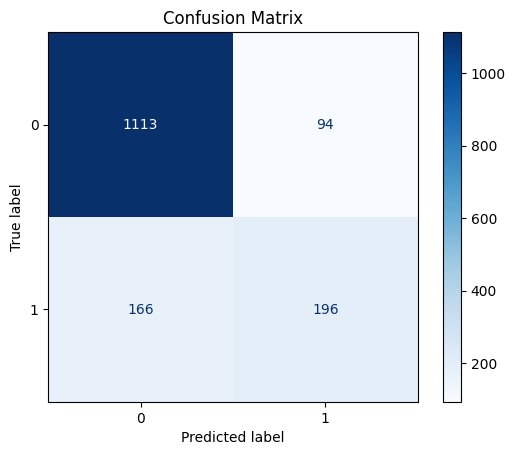

ROC AUC: 0.8808


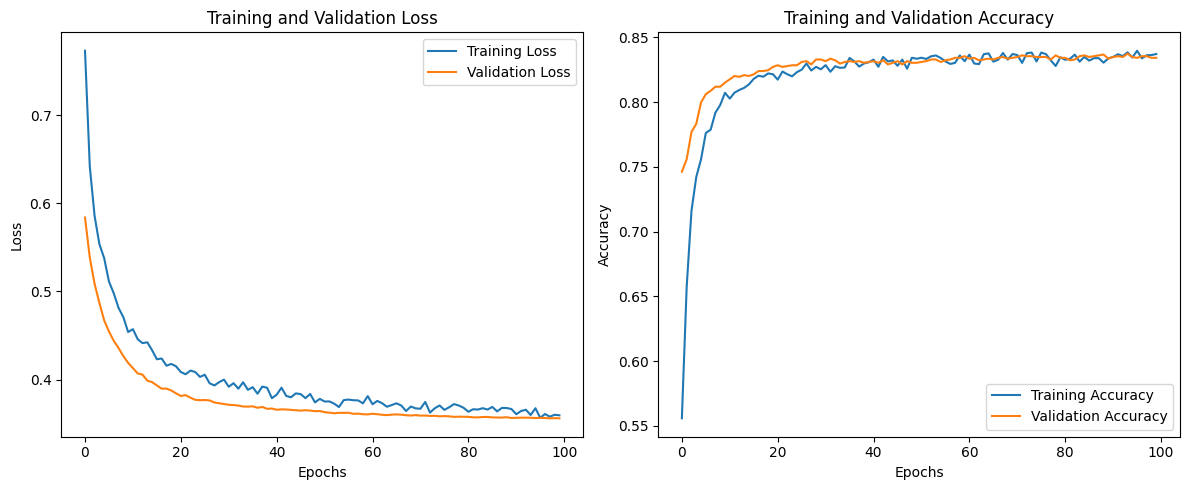

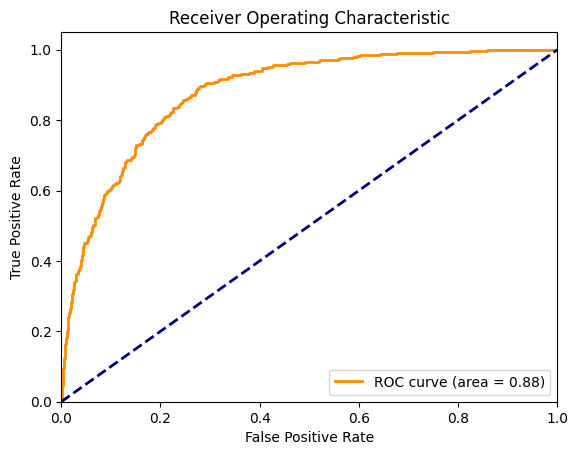

In [ ]:
# ========================
# Section 5: Evaluation and Visualization
# ========================
print("\nEvaluating final model...")

# Generate predictions
y_pred = (final_model.predict(X_test_preprocessed) > 0.5).astype("int32")
y_proba = final_model.predict(X_test_preprocessed)

# Evaluate performance
print("\n" + "="*50)
print(f"Best Architecture: {best_arch}")
print("="*50)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualize confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")

# Plot training history for best model
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
# Check if 'accuracy' or 'acc' is used
acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'

plt.plot(history.history[acc_key], label='Training Accuracy')
plt.plot(history.history[val_acc_key], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

